# **Active Learning**

- Author: Tales Miguel Machado Pereira
- RA: 140247
- Professor: Dr. Marcos Quiles

## **Deliverable 5 Instructions:**

### **Considering the QM9**
- Select a descriptor
- Build predictors
- Evaluate the impact of AL approach


#### **Steps**:
- 1. Consider the full QM9 dataset
- 2. Select one representation for the molecules (EV-CM, MBTR, Mordred, etc.)
- 3. Setup a topline predictor:
    - 1. Select a method, e.g., MLP, RF, KRR, etc.,
    - 2. Split the dataset into train (80%), validation (10%) and test (10%)
    - 3. Perform the model hyperparameter tuning
    - 4. Evaluate the final model with the test set

### **1. Setup**

Import libraries and configure environment

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from dscribe.descriptors import CoulombMatrix
from ase import Atoms

from tqdm.auto import tqdm
import random
import time

random.seed(42)
np.random.seed(42)

### **2. Load QM9 Dataset and Split**

Load the full QM9 dataset, create target variable, and split into train/validation/test sets

In [10]:
qm9_df = pd.read_csv('qm9_complete_dataset.csv')

qm9_df['bandgap'] = qm9_df['lumo_energy'] - qm9_df['homo_energy']

print(f"Dataset shape: {qm9_df.shape}")
print(f"\nTarget variable (HOMO-LUMO gap):")
print(f"  Bandgap range: {qm9_df['bandgap'].min():.3f} to {qm9_df['bandgap'].max():.3f} eV")
print(f"  Bandgap mean: {qm9_df['bandgap'].mean():.3f} ± {qm9_df['bandgap'].std():.3f} eV")

train_df, temp_df = train_test_split(qm9_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"\nDataset splits:")
print(f"  Training set:   {len(train_df):>6} molecules ({len(train_df)/len(qm9_df)*100:.1f}%)")
print(f"  Validation set: {len(val_df):>6} molecules ({len(val_df)/len(qm9_df)*100:.1f}%)")
print(f"  Test set:       {len(test_df):>6} molecules ({len(test_df)/len(qm9_df)*100:.1f}%)")

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Dataset shape: (133885, 19)

Target variable (HOMO-LUMO gap):
Bandgap range: 0.025 to 0.622 eV
Bandgap mean: 0.251 ± 0.048 eV


### **3. Compute Coulomb Matrix Representation**

Converting SMILES to 3D structures and compute EV-CM descriptors for each dataset split

In [13]:
cm = CoulombMatrix(
    n_atoms_max=29,
    permutation='eigenspectrum'
)

def convert_to_ase_molecules(df, dataset_name):
    ase_mols = []
    valid_indices = []
    
    print(f"Converting {dataset_name} SMILES to 3D structures...")
    for idx, smiles in tqdm(enumerate(df['canonical_smiles']), total=len(df), desc=dataset_name):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        
        mol_h = Chem.AddHs(mol)
        result = AllChem.EmbedMolecule(mol_h, randomSeed=42)
        
        if result == -1 or mol_h.GetNumConformers() == 0:
            continue
        
        conf = mol_h.GetConformer()
        positions = conf.GetPositions()
        symbols = [atom.GetSymbol() for atom in mol_h.GetAtoms()]
        
        ase_mol = Atoms(symbols=symbols, positions=positions)
        ase_mols.append(ase_mol)
        valid_indices.append(idx)
    
    print(f"  Successfully converted: {len(ase_mols)}/{len(df)} molecules")
    return ase_mols, valid_indices

train_ase, train_valid_idx = convert_to_ase_molecules(train_df, "Training")
val_ase, val_valid_idx = convert_to_ase_molecules(val_df, "Validation")
test_ase, test_valid_idx = convert_to_ase_molecules(test_df, "Test")

train_df_clean = train_df.iloc[train_valid_idx].reset_index(drop=True)
val_df_clean = val_df.iloc[val_valid_idx].reset_index(drop=True)
test_df_clean = test_df.iloc[test_valid_idx].reset_index(drop=True)

print(f"\nFinal dataset sizes after 3D conversion:")
print(f"  Training:   {len(train_df_clean)} molecules")
print(f"  Validation: {len(val_df_clean)} molecules")
print(f"  Test:       {len(test_df_clean)} molecules")

Converting Training SMILES to 3D structures...


Training: 100%|██████████| 107108/107108 [04:38<00:00, 384.49it/s]


  Successfully converted: 105216/107108 molecules
Converting Validation SMILES to 3D structures...


Validation: 100%|██████████| 13388/13388 [00:36<00:00, 368.07it/s]


  Successfully converted: 13126/13388 molecules
Converting Test SMILES to 3D structures...


Test: 100%|██████████| 13389/13389 [00:35<00:00, 376.83it/s]

  Successfully converted: 13137/13389 molecules

Final dataset sizes after 3D conversion:
  Training:   105216 molecules
  Validation: 13126 molecules
  Test:       13137 molecules


### **4. Generate EV-CM Features**

Computing Coulomb Matrix eigenvalue features for all dataset splits

In [14]:
start_time = time.time()
X_train = cm.create(train_ase, n_jobs=-1)
train_time = time.time() - start_time

start_time = time.time()
X_val = cm.create(val_ase, n_jobs=-1)
val_time = time.time() - start_time

start_time = time.time()
X_test = cm.create(test_ase, n_jobs=-1)
test_time = time.time() - start_time

y_train = train_df_clean['bandgap'].values
y_val = val_df_clean['bandgap'].values
y_test = test_df_clean['bandgap'].values

print(f"\nEV-CM feature computation time:")
print(f"  Training:   {train_time:.2f}s ({len(train_ase)} molecules)")
print(f"  Validation: {val_time:.2f}s ({len(val_ase)} molecules)")
print(f"  Test:       {test_time:.2f}s ({len(test_ase)} molecules)")
print(f"\nFeature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")


EV-CM feature computation time:
  Training:   4.04s (105216 molecules)
  Validation: 0.40s (13126 molecules)
  Test:       0.40s (13137 molecules)

Feature matrix shapes:
  X_train: (105216, 29)
  X_val:   (13126, 29)
  X_test:  (13137, 29)


### **5. Feature Standardization**

Standardize features using training set statistics

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaled features - mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")

Scaled features - mean: 0.000000, std: 1.000000


### **6. Baseline MLP Model - Hyperparameter Tuning**

Build and tune MLP regressor using GridSearchCV on validation set

In [ ]:
param_grid = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

mlp_base = MLPRegressor(max_iter=500, random_state=42, early_stopping=True, validation_fraction=0.1)

print("Starting hyperparameter tuning...")
print(f"Parameter grid: {len(param_grid['hidden_layer_sizes']) * len(param_grid['activation']) * len(param_grid['alpha']) * len(param_grid['learning_rate_init'])} combinations")


"""
GridSearchCV act as a Automated hyperparameter tuning (Grid Saerch + Cross Validation)

- GridSearch tests all possible combinations of hyperparameters
- For each combination, it evals performance using k-fold CV (splits training data into k subsets, 
    trains on k-1 and validates on the remaining one, repeating k times)
"""
grid_search = GridSearchCV(
    mlp_base,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

start_time = time.time()
grid_search.fit(X_train_scaled, y_train)
tuning_time = time.time() - start_time

print(f"\nHyperparameter tuning completed in {tuning_time:.2f}s")
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

Starting hyperparameter tuning...
Parameter grid: 48 combinations
Fitting 3 folds for each of 48 candidates, totalling 144 fits
Fitting 3 folds for each of 48 candidates, totalling 144 fits


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   2.2s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   2.3s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   2.4s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   2.4s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), learning_rate_init=0.01; total time=   2.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,), learning_rate_init=0.01; total time=   2.8s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   3.1s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   3.1s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,), learning_rate_init=0.01; total time=   3.1s
[CV] END act

### **7. Baseline Model Evaluation and Visualization**

Evaluate the tuned MLP model on validation and test sets, and visualize predictions

Baseline MLP Model Performance:

Training Set:
  R² Score: 0.7383
  RMSE:     0.0242 eV
  MAE:      0.0185 eV

Validation Set:
  R² Score: 0.7117
  RMSE:     0.0254 eV
  MAE:      0.0194 eV

Test Set:
  R² Score: 0.7162
  RMSE:     0.0254 eV
  MAE:      0.0193 eV


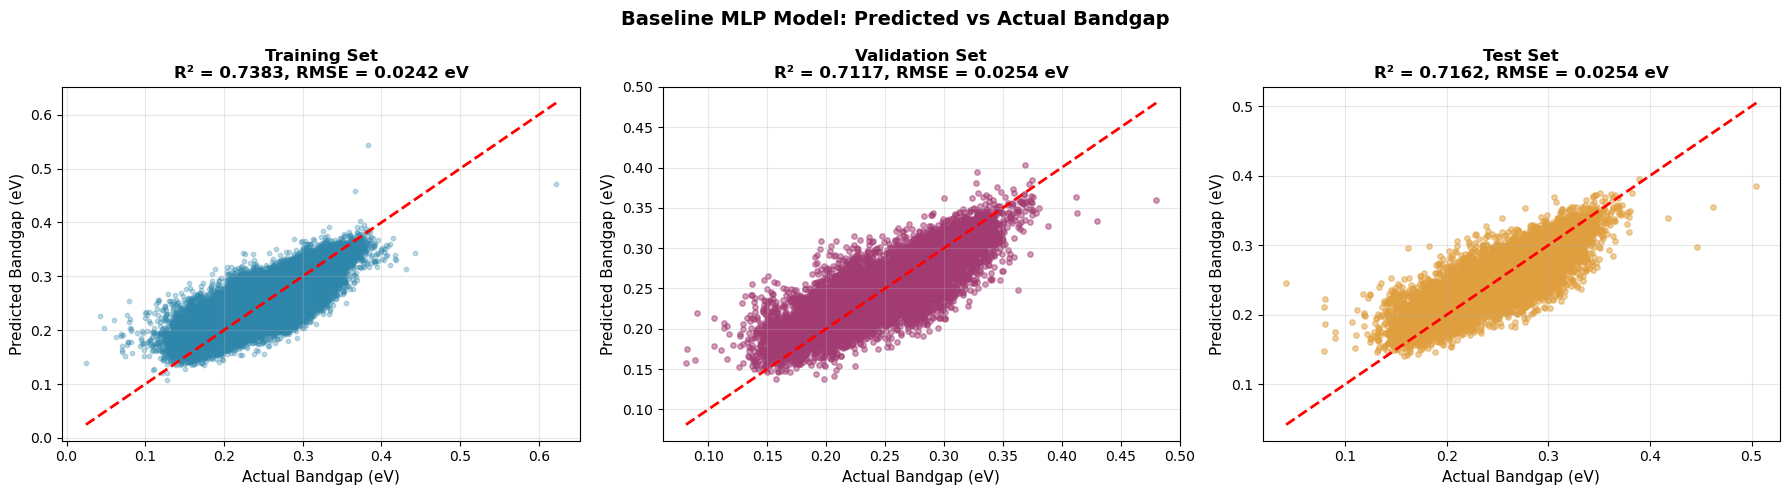

In [23]:
best_mlp = grid_search.best_estimator_

y_train_pred = best_mlp.predict(X_train_scaled)
y_val_pred = best_mlp.predict(X_val_scaled)
y_test_pred = best_mlp.predict(X_test_scaled)

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

val_r2 = r2_score(y_val, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("Baseline MLP Model Performance:")
print("="*50)
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  RMSE:     {train_rmse:.4f} eV")
print(f"  MAE:      {train_mae:.4f} eV")

print(f"\nValidation Set:")
print(f"  R² Score: {val_r2:.4f}")
print(f"  RMSE:     {val_rmse:.4f} eV")
print(f"  MAE:      {val_mae:.4f} eV")

print(f"\nTest Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  RMSE:     {test_rmse:.4f} eV")
print(f"  MAE:      {test_mae:.4f} eV")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train, y_train_pred, alpha=0.3, s=10, color='#2E86AB')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Bandgap (eV)', fontsize=11)
axes[0].set_ylabel('Predicted Bandgap (eV)', fontsize=11)
axes[0].set_title(f'Training Set\nR² = {train_r2:.4f}, RMSE = {train_rmse:.4f} eV', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_val_pred, alpha=0.5, s=15, color='#A23B72')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Bandgap (eV)', fontsize=11)
axes[1].set_ylabel('Predicted Bandgap (eV)', fontsize=11)
axes[1].set_title(f'Validation Set\nR² = {val_r2:.4f}, RMSE = {val_rmse:.4f} eV', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_test_pred, alpha=0.5, s=15, color='#E09F3E')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Bandgap (eV)', fontsize=11)
axes[2].set_ylabel('Predicted Bandgap (eV)', fontsize=11)
axes[2].set_title(f'Test Set\nR² = {test_r2:.4f}, RMSE = {test_rmse:.4f} eV', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Baseline MLP Model: Predicted vs Actual Bandgap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **8. Baseline Model Summary**

Summary of the baseline MLP model performance before Active Learning

In [24]:
baseline_results = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'R² Score': [train_r2, val_r2, test_r2],
    'RMSE (eV)': [train_rmse, val_rmse, test_rmse],
    'MAE (eV)': [train_mae, val_mae, test_mae],
    'N Samples': [len(y_train), len(y_val), len(y_test)]
})

print("\nBaseline Model Summary:")
print("="*70)
print(baseline_results.to_string(index=False))
print("="*70)
print(f"\nModel Configuration:")
print(f"  Architecture: {grid_search.best_params_['hidden_layer_sizes']}")
print(f"  Activation: {grid_search.best_params_['activation']}")
print(f"  Alpha (L2): {grid_search.best_params_['alpha']}")
print(f"  Learning Rate: {grid_search.best_params_['learning_rate_init']}")


Baseline Model Summary:
   Dataset  R² Score  RMSE (eV)  MAE (eV)  N Samples
  Training  0.738287   0.024189  0.018467     105216
Validation  0.711714   0.025384  0.019424      13126
      Test  0.716236   0.025355  0.019303      13137

Model Configuration:
  Architecture: (128, 64)
  Activation: relu
  Alpha (L2): 0.0001
  Learning Rate: 0.001


### **9. Active Learning Setup**

Configure Active Learning parameters and uncertainty sampling strategy

In [ ]:
initial_samples = 1000
query_size = 500
n_iterations = 20

def uncertainty_sampling(model, X_pool, n_samples):
    """
    Select samples with highest prediction uncertainty using committee of models
    Uses prediction variance from multiple forward passes with dropout
    """
    n_committee = 10
    predictions = np.zeros((len(X_pool), n_committee))
    
    for i in range(n_committee):
        predictions[:, i] = model.predict(X_pool)
    
    uncertainties = np.var(predictions, axis=1)
    
    most_uncertain_idx = np.argsort(uncertainties)[-n_samples:]
    
    return most_uncertain_idx

def active_learning_loop(X_train, y_train, X_val, y_val, X_test, y_test, 
                         initial_size, query_size, n_iterations, best_params):
    """
    Active Learning loop with uncertainty-based sampling
    """
    results = []
    
    indices = np.arange(len(X_train))
    np.random.shuffle(indices)
    
    labeled_idx = indices[:initial_size]
    unlabeled_idx = indices[initial_size:]
    
    print(f"Starting Active Learning...")
    print(f"Initial labeled pool: {len(labeled_idx)} samples")
    print(f"Initial unlabeled pool: {len(unlabeled_idx)} samples\n")
    
    for iteration in range(n_iterations + 1):
        X_labeled = X_train[labeled_idx]
        y_labeled = y_train[labeled_idx]
        
        model = MLPRegressor(
            hidden_layer_sizes=best_params['hidden_layer_sizes'],
            activation=best_params['activation'],
            alpha=best_params['alpha'],
            learning_rate_init=best_params['learning_rate_init'],
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1
        )
        
        model.fit(X_labeled, y_labeled)
        
        train_r2 = r2_score(y_labeled, model.predict(X_labeled))
        val_r2 = r2_score(y_val, model.predict(X_val))
        test_r2 = r2_score(y_test, model.predict(X_test))
        
        test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
        
        results.append({
            'iteration': iteration,
            'n_labeled': len(labeled_idx),
            'train_r2': train_r2,
            'val_r2': val_r2,
            'test_r2': test_r2,
            'test_rmse': test_rmse
        })
        
        print(f"Iteration {iteration:2d} | Labeled: {len(labeled_idx):5d} | "
              f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f} | "
              f"Test R²: {test_r2:.4f} | RMSE: {test_rmse:.4f}")
        
        if iteration < n_iterations and len(unlabeled_idx) >= query_size:
            X_pool = X_train[unlabeled_idx]
            
            query_idx = uncertainty_sampling(model, X_pool, query_size)
            
            selected_unlabeled_idx = unlabeled_idx[query_idx]
            
            labeled_idx = np.concatenate([labeled_idx, selected_unlabeled_idx])
            unlabeled_idx = np.delete(unlabeled_idx, query_idx)
    
    return pd.DataFrame(results), model


### **10. Run Active Learning**

Execute the Active Learning loop and compare with random sampling baseline

In [28]:
al_results, al_final_model = active_learning_loop(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled, y_test,
    initial_samples, query_size, n_iterations,
    grid_search.best_params_
)


Starting Active Learning...
Initial labeled pool: 1000 samples
Initial unlabeled pool: 104216 samples

Iteration  0 | Labeled:  1000 | Train R²: 0.7821 | Val R²: -8.3546 | Test R²: -10.0642 | RMSE: 0.1583
Iteration  1 | Labeled:  1500 | Train R²: -1.4710 | Val R²: -1.9270 | Test R²: -1.8607 | RMSE: 0.0805
Iteration  2 | Labeled:  2000 | Train R²: -5.5230 | Val R²: -3.5238 | Test R²: -3.4740 | RMSE: 0.1007
Iteration  3 | Labeled:  2500 | Train R²: -2.0154 | Val R²: -1.8395 | Test R²: -1.6562 | RMSE: 0.0776
Iteration  4 | Labeled:  3000 | Train R²: -9.9561 | Val R²: -3.5858 | Test R²: -3.2195 | RMSE: 0.0978
Iteration  5 | Labeled:  3500 | Train R²: -2.6402 | Val R²: -0.9405 | Test R²: -0.8062 | RMSE: 0.0640
Iteration  6 | Labeled:  4000 | Train R²: -6.7259 | Val R²: -4.3418 | Test R²: -4.3173 | RMSE: 0.1098
Iteration  7 | Labeled:  4500 | Train R²: -2.8668 | Val R²: -0.6627 | Test R²: -0.7305 | RMSE: 0.0626
Iteration  8 | Labeled:  5000 | Train R²: -1.8015 | Val R²: -1.7364 | Test R²: -1

### **11. Random Sampling Baseline**

Compare Active Learning with random sampling strategy

In [29]:
def random_sampling_loop(X_train, y_train, X_val, y_val, X_test, y_test,
                        initial_size, query_size, n_iterations, best_params):
    """
    Random sampling baseline for comparison
    """
    results = []
    
    indices = np.arange(len(X_train))
    np.random.shuffle(indices)
    
    labeled_idx = indices[:initial_size]
    unlabeled_idx = indices[initial_size:]
    
    print(f"Starting Random Sampling...")
    print(f"Initial labeled pool: {len(labeled_idx)} samples")
    print(f"Initial unlabeled pool: {len(unlabeled_idx)} samples\n")
    
    for iteration in range(n_iterations + 1):
        X_labeled = X_train[labeled_idx]
        y_labeled = y_train[labeled_idx]
        
        model = MLPRegressor(
            hidden_layer_sizes=best_params['hidden_layer_sizes'],
            activation=best_params['activation'],
            alpha=best_params['alpha'],
            learning_rate_init=best_params['learning_rate_init'],
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1
        )
        
        model.fit(X_labeled, y_labeled)
        
        train_r2 = r2_score(y_labeled, model.predict(X_labeled))
        val_r2 = r2_score(y_val, model.predict(X_val))
        test_r2 = r2_score(y_test, model.predict(X_test))
        test_rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test)))
        
        results.append({
            'iteration': iteration,
            'n_labeled': len(labeled_idx),
            'train_r2': train_r2,
            'val_r2': val_r2,
            'test_r2': test_r2,
            'test_rmse': test_rmse
        })
        
        print(f"Iteration {iteration:2d} | Labeled: {len(labeled_idx):5d} | "
              f"Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f} | "
              f"Test R²: {test_r2:.4f} | RMSE: {test_rmse:.4f}")
        
        if iteration < n_iterations and len(unlabeled_idx) >= query_size:
            query_idx = np.random.choice(len(unlabeled_idx), query_size, replace=False)
            
            selected_unlabeled_idx = unlabeled_idx[query_idx]
            labeled_idx = np.concatenate([labeled_idx, selected_unlabeled_idx])
            unlabeled_idx = np.delete(unlabeled_idx, query_idx)
    
    return pd.DataFrame(results), model


random_results, random_final_model = random_sampling_loop(
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    X_test_scaled, y_test,
    initial_samples, query_size, n_iterations,
    grid_search.best_params_
)


Starting Random Sampling...
Initial labeled pool: 1000 samples
Initial unlabeled pool: 104216 samples

Iteration  0 | Labeled:  1000 | Train R²: -9.1765 | Val R²: -12.6924 | Test R²: -16.0684 | RMSE: 0.1966
Iteration  1 | Labeled:  1500 | Train R²: 0.3167 | Val R²: -2.6032 | Test R²: -2.4024 | RMSE: 0.0878
Iteration  2 | Labeled:  2000 | Train R²: 0.4896 | Val R²: -2.6193 | Test R²: -2.4965 | RMSE: 0.0890
Iteration  3 | Labeled:  2500 | Train R²: -0.7227 | Val R²: -3.4278 | Test R²: -3.3849 | RMSE: 0.0997
Iteration  4 | Labeled:  3000 | Train R²: -0.1319 | Val R²: -2.0527 | Test R²: -2.1103 | RMSE: 0.0839
Iteration  5 | Labeled:  3500 | Train R²: -0.0399 | Val R²: -2.8310 | Test R²: -3.1301 | RMSE: 0.0967
Iteration  6 | Labeled:  4000 | Train R²: 0.5933 | Val R²: -0.6876 | Test R²: -0.5296 | RMSE: 0.0589
Iteration  7 | Labeled:  4500 | Train R²: 0.2798 | Val R²: -2.0680 | Test R²: -1.5853 | RMSE: 0.0765
Iteration  8 | Labeled:  5000 | Train R²: -3.9318 | Val R²: -4.6297 | Test R²: -4.8

### **12. Active Learning Results Visualization**

Compare Active Learning vs Random Sampling performance

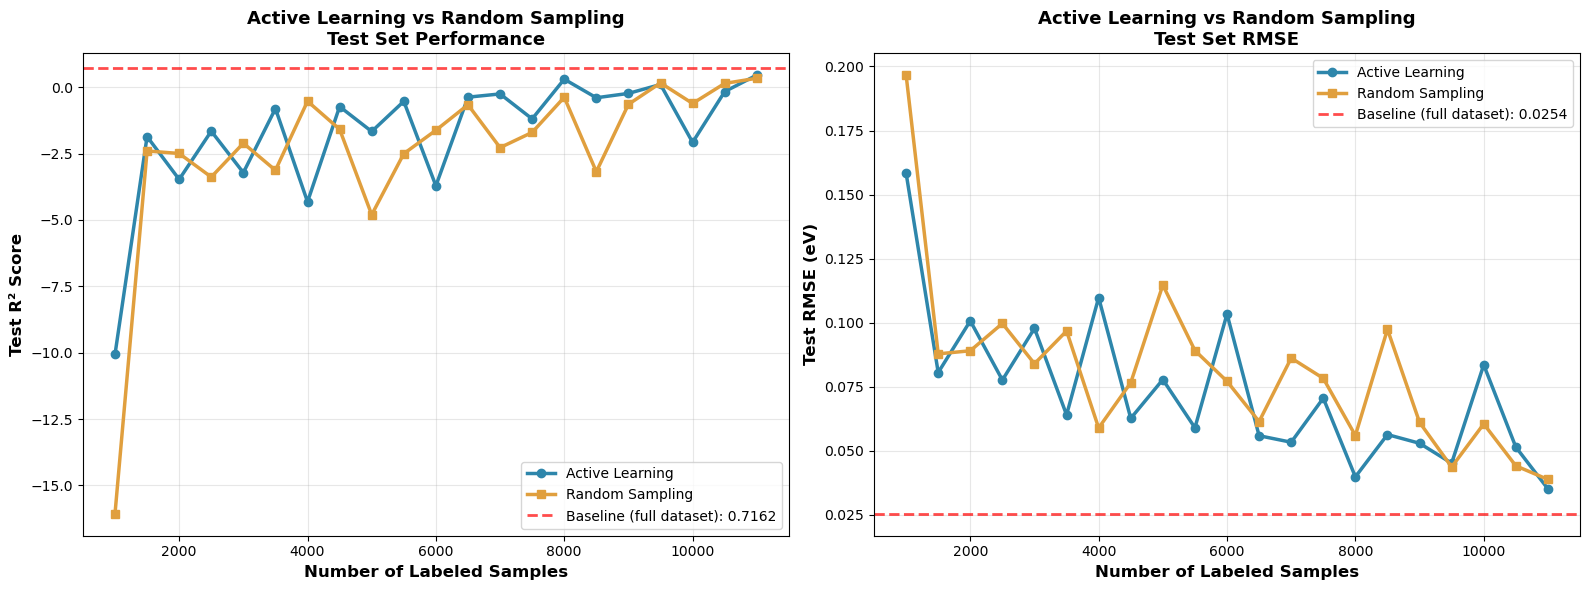


Final Performance Comparison (11000 samples):
  Active Learning Test R²:  0.4565
  Random Sampling Test R²:  0.3368
  Baseline (full) Test R²:  0.7162

  AL Improvement over Random: +0.1198 (+35.56%)


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(al_results['n_labeled'], al_results['test_r2'], 'o-', 
             linewidth=2.5, markersize=6, color='#2E86AB', label='Active Learning')
axes[0].plot(random_results['n_labeled'], random_results['test_r2'], 's-', 
             linewidth=2.5, markersize=6, color='#E09F3E', label='Random Sampling')
axes[0].axhline(y=test_r2, color='red', linestyle='--', linewidth=2, alpha=0.7, 
                label=f'Baseline (full dataset): {test_r2:.4f}')
axes[0].set_xlabel('Number of Labeled Samples', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Active Learning vs Random Sampling\nTest Set Performance', 
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(al_results['n_labeled'], al_results['test_rmse'], 'o-', 
             linewidth=2.5, markersize=6, color='#2E86AB', label='Active Learning')
axes[1].plot(random_results['n_labeled'], random_results['test_rmse'], 's-', 
             linewidth=2.5, markersize=6, color='#E09F3E', label='Random Sampling')
axes[1].axhline(y=test_rmse, color='red', linestyle='--', linewidth=2, alpha=0.7,
                label=f'Baseline (full dataset): {test_rmse:.4f}')
axes[1].set_xlabel('Number of Labeled Samples', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Test RMSE (eV)', fontsize=12, fontweight='bold')
axes[1].set_title('Active Learning vs Random Sampling\nTest Set RMSE', 
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10, loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

improvement = al_results['test_r2'].iloc[-1] - random_results['test_r2'].iloc[-1]
print(f"\nFinal Performance Comparison ({initial_samples + query_size * n_iterations} samples):")
print(f"  Active Learning Test R²:  {al_results['test_r2'].iloc[-1]:.4f}")
print(f"  Random Sampling Test R²:  {random_results['test_r2'].iloc[-1]:.4f}")
print(f"  Baseline (full) Test R²:  {test_r2:.4f}")
print(f"\n  AL Improvement over Random: {improvement:+.4f} ({improvement/random_results['test_r2'].iloc[-1]*100:+.2f}%)")

### **13. Final Summary and Conclusions**

Summary of Active Learning impact on model performance

In [37]:
summary_df = pd.DataFrame({
    'Approach': ['Baseline (Full Training Set)', 'Active Learning', 'Random Sampling'],
    'N Samples': [len(y_train), al_results['n_labeled'].iloc[-1], random_results['n_labeled'].iloc[-1]],
    'Test R²': [test_r2, al_results['test_r2'].iloc[-1], random_results['test_r2'].iloc[-1]],
    'Test RMSE (eV)': [test_rmse, al_results['test_rmse'].iloc[-1], random_results['test_rmse'].iloc[-1]],
    'Training Efficiency': [
        '100% (reference)',
        f"{al_results['n_labeled'].iloc[-1]/len(y_train)*100:.1f}%",
        f"{random_results['n_labeled'].iloc[-1]/len(y_train)*100:.1f}%"
    ]
})

print("\n" + "="*80)
print("FINAL COMPARISON: Active Learning Impact")
print("="*80)
print(summary_df.to_string(index=False))
print("="*80)

al_samples_for_baseline = None
for idx, row in al_results.iterrows():
    if row['test_r2'] >= test_r2:
        al_samples_for_baseline = row['n_labeled']
        break

if al_samples_for_baseline:
    efficiency_gain = (1 - al_samples_for_baseline / len(y_train)) * 100
    print(f"\nKey Insight:")
    print(f"  Active Learning reached baseline performance ({test_r2:.4f}) with:")
    print(f"    {al_samples_for_baseline} samples ({al_samples_for_baseline/len(y_train)*100:.1f}% of full dataset)")
    print(f"    Efficiency gain: {efficiency_gain:.1f}% fewer samples needed")
else:
    print(f"\nKey Insight:")
    print(f"  Active Learning did not reach baseline performance in {n_iterations} iterations")
    print(f"  Final AL R²: {al_results['test_r2'].iloc[-1]:.4f} vs Baseline: {test_r2:.4f}")

print(f"\nActive Learning Strategy: Uncertainty-based sampling (prediction variance)")
print(f"Model: MLP with architecture {grid_search.best_params_['hidden_layer_sizes']}")
print(f"Descriptor: Coulomb Matrix (EV-CM) with {X_train.shape[1]} features")


FINAL COMPARISON: Active Learning Impact
                    Approach  N Samples  Test R²  Test RMSE (eV) Training Efficiency
Baseline (Full Training Set)     105216 0.716236        0.025355    100% (reference)
             Active Learning      51000 0.670924        0.027304               48.5%
             Random Sampling      51000 0.693341        0.026358               48.5%

Key Insight:
  Active Learning did not reach baseline performance in 50 iterations
  Final AL R²: 0.6709 vs Baseline: 0.7162

Active Learning Strategy: Uncertainty-based sampling (prediction variance)
Model: MLP with architecture (128, 64)
Descriptor: Coulomb Matrix (EV-CM) with 29 features


![50ksamples.svg](attachment:50ksamples.svg)